In [1]:
import json
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import coo_matrix
from sklearn.metrics.pairwise import cosine_similarity

import networkx as nx
import igraph as ig

path = '/home/ysjang/python/social/yelp_dataset/'

In [3]:
# Review
# data load
file_name = 'yelp_academic_dataset_review.json'

data_file = open(path + file_name)

data = []
for line in data_file:
    data.append(json.loads(line))

data_file.close()
df_review = pd.DataFrame(data)

print(df_review.shape)
print(df_review.columns)
df_review.head()

(6990280, 9)
Index(['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny',
       'cool', 'text', 'date'],
      dtype='object')


,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15


In [4]:
# Social Network
# data load
file_name = 'yelp_academic_dataset_user.json'

data_file = open(path + file_name)

data = []
for line in data_file:
    data.append(json.loads(line))

data_file.close()
df_friend = pd.DataFrame(data)

print(df_friend.shape)
df_friend.head()

(1987897, 22)


,user_id,name,review_count,yelping_since,useful,funny,cool,elite,friends,fans,...,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos
0,qVc8ODYU5SZjKXVBgXdI7w,Walker,585,2007-01-25 16:47:26,7217,1259,5994,2007,"NSCy54eWehBJyZdG2iE84w, pe42u7DcCH2QmI81NX-8qA...",267,...,65,55,56,18,232,844,467,467,239,180
1,j14WgRoU_-2ZE1aw1dXrJg,Daniel,4333,2009-01-25 04:35:42,43091,13066,27281,"2009,2010,2011,2012,2013,2014,2015,2016,2017,2...","ueRPE0CX75ePGMqOFVj6IQ, 52oH4DrRvzzl8wh5UXyU0A...",3138,...,264,184,157,251,1847,7054,3131,3131,1521,1946
2,2WnXYQFK0hXEoTxPtV2zvg,Steph,665,2008-07-25 10:41:00,2086,1010,1003,"2009,2010,2011,2012,2013","LuO3Bn4f3rlhyHIaNfTlnA, j9B4XdHUhDfTKVecyWQgyA...",52,...,13,10,17,3,66,96,119,119,35,18
3,SZDeASXq7o05mMNLshsdIA,Gwen,224,2005-11-29 04:38:33,512,330,299,"2009,2010,2011","enx1vVPnfdNUdPho6PH_wg, 4wOcvMLtU6a9Lslggq74Vg...",28,...,4,1,6,2,12,16,26,26,10,9
4,hA5lMy-EnncsH4JoR-hFGQ,Karen,79,2007-01-05 19:40:59,29,15,7,,"PBK4q9KEEBHhFvSXCUirIw, 3FWPpM7KU1gXeOM_ZbYMbA...",1,...,1,0,0,0,1,1,0,0,0,0


In [5]:
# 리뷰를 n개 이상 남긴 유저만 고려
n = 50
# top_k = 5

In [6]:
review_cnt = df_review['user_id'].value_counts(ascending = False)
review_cnt = review_cnt[1:] # 리뷰 3000개 유저 제거

valid_user = review_cnt.loc[review_cnt >= n].index

In [7]:
df_review_filtered = df_review.loc[df_review['user_id'].isin(valid_user)].reset_index(drop = True)
print(f'리뷰 {n}개 이상 남긴 df:', df_review_filtered.shape)

df_friend_filtered = df_friend.loc[df_friend['user_id'].isin(valid_user)].reset_index(drop = True)
print(f'소셜네트워크에서 리뷰 {n}개 이상 남긴 df:', df_friend_filtered.shape)

리뷰 50개 이상 남긴 df: (1399938, 9)
소셜네트워크에서 리뷰 50개 이상 남긴 df: (12629, 22)


In [8]:
df_review_filtered.info()
print('\n')
df_friend_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1399938 entries, 0 to 1399937
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   review_id    1399938 non-null  object 
 1   user_id      1399938 non-null  object 
 2   business_id  1399938 non-null  object 
 3   stars        1399938 non-null  float64
 4   useful       1399938 non-null  int64  
 5   funny        1399938 non-null  int64  
 6   cool         1399938 non-null  int64  
 7   text         1399938 non-null  object 
 8   date         1399938 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 96.1+ MB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12629 entries, 0 to 12628
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             12629 non-null  object 
 1   name                12629 non-null  object 
 2   review_count        12629 non

Text(0, 0.5, 'Frequency')

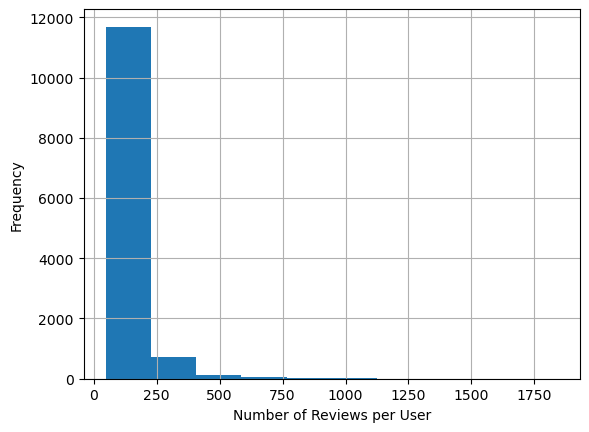

In [9]:
fil = review_cnt.loc[(review_cnt >= n)]
fil.hist(bins=10)
plt.xlabel("Number of Reviews per User")
plt.ylabel("Frequency")

In [ ]:
review_cnt

1987928

In [14]:
# 리뷰를 n개 이상 남긴 유저 비율
def coverage(n):
    return (review_cnt >= n).mean()
def num(n):
    return (review_cnt >= n).sum()

for i in [1, 5, 10, 20, 30, 50, 100, 200, 500, 1000]:
    print(i, coverage(i))

for i in [1, 5, 10, 20, 30, 50, 100, 200, 500, 1000]:
    print(i, num(i))


1 1.0
5 0.14442927510453094
10 0.059040870695518145
20 0.022591361457759033
30 0.012847044762184547
50 0.00635284577711064
100 0.0021952505322124344
200 0.0006157164645802061
500 7.243723112708307e-05
1000 1.0060726545428204e-05
1 1987928
5 287115
10 117369
20 44910
30 25539
50 12629
100 4364
200 1224
500 144
1000 20


In [10]:
# rating matrix 생성
temp = df_review_filtered[['user_id', 'business_id', 'stars']]
temp = temp.copy()

temp['user_cat'] = temp['user_id'].astype('category')
temp['user_idx'] = temp['user_cat'].cat.codes

temp['business_cat'] = temp['business_id'].astype('category')
temp['business_idx'] = temp['business_cat'].cat.codes

rating_mat = coo_matrix((temp['stars'], (temp['user_idx'], temp['business_idx'])))
rating_mat = rating_mat.tocsr()
rating_mat

<12629x122649 sparse matrix of type '<class 'numpy.float64'>'
	with 1302825 stored elements in Compressed Sparse Row format>

In [126]:
# # cosine similiarity without null
# def cos_wo_null(u, v):
#     mask = (u != 0) & (v != 0)

#     if np.sum(mask) == 0:
#         return 0
    
#     u_mask = u[mask]
#     v_mask = v[mask]

#     return np.dot(u_mask, v_mask) / (np.linalg.norm(u_mask) * np.linalg.norm(v_mask))


# def cos_wo_null_csr(u, v):
#     u_idx = set(u.indices)   
#     v_idx = set(v.indices)

#     inter = np.array(list(u_idx & v_idx))
#     if len(inter) == 0:
#         return 0.0
    
#     u_vals = u[0, inter].A.ravel()
#     v_vals = v[0, inter].A.ravel()

#     denom = np.linalg.norm(u_vals) * np.linalg.norm(v_vals)
#     if denom == 0:
#         return 0.0
    
#     return np.dot(u_vals, v_vals) / denom

# num_users = rating_mat.shape[0]
# rows = []

# for i in range(num_users):
#     u = rating_mat[i]

#     for j in range(i+1, num_users):

#         v = rating_mat[j]
#         sim = cos_wo_null_csr(u, v)

#         rows.append([i, j, sim])
#         # rows.append([j, i, sim])

# df_sim = pd.DataFrame(rows, columns = ['user1', 'user2', 'cos_sim'])
# df_sim

In [127]:
# cosine similiarity without null
dot_mat = rating_mat @ rating_mat.T
sq_mat = rating_mat.power(2)
ind_mat = rating_mat > 0

norm_u2 = sq_mat @ ind_mat.T
norm_v2 = ind_mat @ sq_mat.T

# cosine similarity 계산
cosine_mat = dot_mat.toarray() / np.sqrt(norm_u2.toarray() * norm_v2.toarray())

cosine_mat[np.isnan(cosine_mat)] = 0
cosine_mat[np.isinf(cosine_mat)] = 0

# 자기 자신 similarity 제거
# np.fill_diagonal(cosine_mat, 0)

num_users = cosine_mat.shape[0]

user_idx1, user_idx2 = np.indices((num_users, num_users))
user_idx1 = user_idx1.ravel()
user_idx2 = user_idx2.ravel()

rows = np.vstack([user_idx1, user_idx2, cosine_mat.ravel()]).T

df_cos_sim = pd.DataFrame(rows, columns=['user_idx', 'neighbor_idx', 'cos_sim'])
df_cos_sim

/tmp/ipykernel_4180343/1630329329.py:10: RuntimeWarning: invalid value encountered in divide
  cosine_mat = dot_mat.toarray() / np.sqrt(norm_u2.toarray() * norm_v2.toarray())


,user_idx,neighbor_idx,cos_sim
0,0.0,0.0,1.0
1,0.0,1.0,0.0
2,0.0,2.0,0.0
3,0.0,3.0,0.0
4,0.0,4.0,0.0
...,...,...,...
159491636,12628.0,12624.0,0.0
159491637,12628.0,12625.0,0.0
159491638,12628.0,12626.0,0.0
159491639,12628.0,12627.0,0.0


In [128]:
import numpy as np
import pandas as pd

# Boolean matrix: 사용자가 어떤 item을 평가했는지 (1 or 0)
ind_mat = (rating_mat > 0).astype(int)

# 1. |I_u ∩ I_v|  : 공통 평가 item 개수
intersection = ind_mat @ ind_mat.T      # CSR × CSR → fast
intersection = intersection.toarray()

# 2. |I_u|, |I_v|
row_sum = ind_mat.sum(axis=1).A1        # 각 사용자별 평가 item 개수

# 3. |I_u ∪ I_v|
# union = |I_u| + |I_v| - |I_u ∩ I_v|
union = row_sum[:, None] + row_sum[None, :] - intersection

# 4. Jaccard similarity = intersection / union
jaccard_mat = intersection / union
jaccard_mat[np.isnan(jaccard_mat)] = 0   # division by zero → 0
jaccard_mat[np.isinf(jaccard_mat)] = 0

# 5. DataFrame 만들기 (전체 pair)
num_users = jaccard_mat.shape[0]
user_idx1, user_idx2 = np.indices((num_users, num_users))

rows = np.vstack([
    user_idx1.ravel(),
    user_idx2.ravel(),
    jaccard_mat.ravel()
]).T

df_jaccard = pd.DataFrame(rows, columns=['user_idx', 'neighbor_idx', 'jaccard_sim'])
df_jaccard
# df_cos_sim

,user_idx,neighbor_idx,jaccard_sim
0,0.0,0.0,1.0
1,0.0,1.0,0.0
2,0.0,2.0,0.0
3,0.0,3.0,0.0
4,0.0,4.0,0.0
...,...,...,...
159491636,12628.0,12624.0,0.0
159491637,12628.0,12625.0,0.0
159491638,12628.0,12626.0,0.0
159491639,12628.0,12627.0,0.0


In [129]:
# cosine similiarity without null
dot_mat = rating_mat @ rating_mat.T
sq_mat = rating_mat.power(2)
ind_mat = rating_mat > 0

norm_u2 = sq_mat @ ind_mat.T
norm_v2 = ind_mat @ sq_mat.T

# cosine similarity 계산
cosine_mat = dot_mat.toarray() / np.sqrt(norm_u2.toarray() * norm_v2.toarray())

cosine_mat[np.isnan(cosine_mat)] = 0
cosine_mat[np.isinf(cosine_mat)] = 0

# 자기 자신 similarity 제거
# np.fill_diagonal(cosine_mat, 0)
cosine_mat

/tmp/ipykernel_4180343/2308528339.py:10: RuntimeWarning: invalid value encountered in divide
  cosine_mat = dot_mat.toarray() / np.sqrt(norm_u2.toarray() * norm_v2.toarray())


array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [130]:
# 이미 있는 변수들 활용:
# dot_mat, norm_u2, norm_v2

dotA = dot_mat.toarray()
norm_u2A = norm_u2.toarray()
norm_v2A = norm_v2.toarray()

dist_mat = np.sqrt(norm_u2A + norm_v2A - 2 * dotA)

# NaN → 0 처리
dist_mat[np.isnan(dist_mat)] = 0
dist_mat[np.isinf(dist_mat)] = 0

dist_mat

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [131]:
# jaccard
ind_mat = (rating_mat > 0).astype(int)
intersection = ind_mat @ ind_mat.T
intersection = intersection.toarray()

row_sum = ind_mat.sum(axis=1).A1

union = row_sum[:, None] + row_sum[None, :] - intersection

jaccard_mat = intersection / union
jaccard_mat[np.isnan(jaccard_mat)] = 0
jaccard_mat[np.isinf(jaccard_mat)] = 0
jaccard_mat

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [132]:
num_users = cosine_mat.shape[0]

user_idx1, user_idx2 = np.indices((num_users, num_users))
user_idx1 = user_idx1.ravel()
user_idx2 = user_idx2.ravel()

rows = np.vstack([user_idx1, user_idx2, cosine_mat.ravel(), dist_mat.ravel() ,jaccard_mat.ravel()]).T

df_sim = pd.DataFrame(rows, columns=['user_idx', 'neighbor_idx', 'cos_sim', 'euc_dist', 'jcd_sim'])
df_sim

,user_idx,neighbor_idx,cos_sim,euc_dist,jcd_sim
0,0.0,0.0,1.0,0.0,1.0
1,0.0,1.0,0.0,0.0,0.0
2,0.0,2.0,0.0,0.0,0.0
3,0.0,3.0,0.0,0.0,0.0
4,0.0,4.0,0.0,0.0,0.0
...,...,...,...,...,...
159491636,12628.0,12624.0,0.0,0.0,0.0
159491637,12628.0,12625.0,0.0,0.0,0.0
159491638,12628.0,12626.0,0.0,0.0,0.0
159491639,12628.0,12627.0,0.0,0.0,0.0


In [133]:
# # 코사인 유사도 top_k명
# num_users = rating_mat.shape[0]

# rows = []

# for i in range(num_users):
#     target_user = rating_mat[i]

#     sim = cosine_similarity(target_user, rating_mat).flatten()
#     sim[i] = -1 # 자기 자신 제거

#     top_idx = np.argsort(sim)[-top_k:][::-1]

#     for neigh in top_idx:
#         rows.append([i, neigh, sim[neigh]])

# df_sim = pd.DataFrame(rows, columns = ['user_idx', 'neighbor_idx', 'similarity'])
# print(df_sim.info())
# df_sim.head()


In [134]:
# # 저장
# df_sim.to_csv('df_dim.csv', index = False)

# # 다시 불러오기
# df_sim = pd.read_csv('df_sim.csv')

In [135]:
# 테스트
# df_friend_filtered_temp = df_friend_filtered[:1000]
df_friend_filtered_temp = df_friend_filtered
df_friend_filtered_temp

G = nx.Graph()

# 유저 ID 리스트
for idx, row in df_friend_filtered_temp.iterrows():
    user = row['user_id']

    # 친구 목록 (쉼표로 split)
    if pd.notna(row['friends']):
        friends = [f.strip() for f in row['friends'].split(',')]
    else:
        friends = []

    # 그래프에 간선 추가
    for friend in friends:
        G.add_edge(user, friend)

print("그래프 노드 수:", G.number_of_nodes())
print("그래프 엣지 수:", G.number_of_edges())

그래프 노드 수: 1195631
그래프 엣지 수: 2408355


In [136]:
# rows = []
# user_list = df_friend_filtered_temp['user_id'].tolist()

# for user in user_list:
#     row = df_friend_filtered_temp.loc[df_friend_filtered_temp['user_id'] == user].iloc[0]

#     # 친구 목록 뽑기
#     if pd.notna(row['friends']):
#         friend_list = [f.strip() for f in row['friends'].split(',')]
#     else:
#         friend_list = []

#     lengths = nx.single_source_shortest_path_length(G, user)

#     # 3. 친구들에 대한 거리만 추출
#     for f in friend_list:
#         dist = lengths.get(f, None)   # 경로 없으면 None
#         rows.append([user, f, dist])

# df_user_dist = pd.DataFrame(rows, columns=['user_id', 'friend_id', 'shortest_path'])
# df_user_dist

In [137]:
users = df_friend_filtered_temp['user_id'].tolist()
rows = []

for u1 in users:
    lengths = nx.single_source_shortest_path_length(G, u1)

    for u2 in users:
        if u1 == u2: continue

        dist = lengths.get(u2, None)
        rows.append([u1, u2, dist])

df_dist = pd.DataFrame(rows, columns = ["user1", "user2", "shortest_path"])
df_dist
# df_dist_reduced = df_dist[df_dist['user1'] < df_dist['user2']].copy()
# df_dist_reduced.reset_index(drop=True, inplace=True)

# # del df_dist
# # import gc
# # gc.collect()

# print(df_dist_reduced.info())
# print(df_dist_reduced.head())

,user1,user2,shortest_path
0,j14WgRoU_-2ZE1aw1dXrJg,MGPQVLsODMm9ZtYQW-g_OA,2.0
1,j14WgRoU_-2ZE1aw1dXrJg,NIhcRW6DWvk1JQhDhXwgOQ,2.0
2,j14WgRoU_-2ZE1aw1dXrJg,rppTTi-kfF8-qyiArNemag,2.0
3,j14WgRoU_-2ZE1aw1dXrJg,AkBtT43dYcttxQ3qOzPBAg,2.0
4,j14WgRoU_-2ZE1aw1dXrJg,IpLRJY4CP3fXtlEd8Y4GFQ,2.0
...,...,...,...
159479007,eCl5_6mKC54Mjk392xUgWQ,jFckZv_dAGGvN2Uo_pfLJg,4.0
159479008,eCl5_6mKC54Mjk392xUgWQ,I6x-ZBHeCNlMnmtfUVf5lg,4.0
159479009,eCl5_6mKC54Mjk392xUgWQ,oEuneH6y_Ki1Rt4JVgkdCQ,NaN
159479010,eCl5_6mKC54Mjk392xUgWQ,-M9cyh6nLa3C6VY_usk4vA,4.0


In [138]:
# # 시각화
# user = "ouODopBKF3AqfCkuQEnrDg"

# # Ego graph
# ego = nx.ego_graph(G, user, radius=1)

# plt.figure(figsize=(8, 8))
# nx.draw(ego, with_labels=False, node_size=30)
# plt.title("Ego-network of user")
# plt.show()

In [139]:
# # index to id 매핑
user_idx_to_id = dict(enumerate(temp['user_cat'].cat.categories))
# user_idx_to_id

# id to index 매핑
user_id_to_idx = {v: k for k, v in user_idx_to_id.items()}
user_id_to_idx


{'--Vu3Gux9nPnLcG9yO_HxA': 0,
 '--_H9j6ggxvqhh9nPofZwg': 1,
 '--_r6E98SNIrGU7weyNxbw': 2,
 '--u09WAjW741FdfkJXxNmg': 3,
 '-0YrXUvXz8112yHap35V2g': 4,
 '-1C-Lu0NTlYi4XB82ntKtg': 5,
 '-1MF2tosrw2WcCxeVNk81Q': 6,
 '-1WbN1Qd-opw8u3uEqs2Kg': 7,
 '-1awBy86Qgr3aN30_Z3xGw': 8,
 '-2U8X6XX1NV1mYX-2MCtKg': 9,
 '-2cKJFFNJ9XVyWBt62mWvA': 10,
 '-2nNiAnDaSbQayynsqgL6Q': 11,
 '-3HYmxW_5Gsg4I0eH3ju-Q': 12,
 '-3agoL-p87vZteiDzrz5og': 13,
 '-3s52C4zL_DHRK0ULG6qtg': 14,
 '-4mjLXqAoAtQjqDFo9q9WQ': 15,
 '-4qa2JVDEC_QPVWcZ1nHkQ': 16,
 '-4vkTh2rImD8c0-30h2uvw': 17,
 '-584avr5GMIqv-9Ut85Ywg': 18,
 '-5jhwwoyXYRzQ0-sr2HCBg': 19,
 '-6Fk7QmNWJDaDKwwcgS8PQ': 20,
 '-6YHxNhkE2hcT-YGVqjI0Q': 21,
 '-7-d8x5w5c9QolAMgPTKZg': 22,
 '-7XrSrJfHndHc_taEXurTw': 23,
 '-7qUbOVWJp2NT3f_TNuIBA': 24,
 '-8PU0Z4Q2Nc-sY0eBj4DiQ': 25,
 '-9OEoNjcLa9nBiu41nHiaQ': 26,
 '-9QrNxZ0l0cSbTYXPlsu_g': 27,
 '-A7wqNBMClbU6Y8NNLdMvw': 28,
 '-AnMcazI_LSSLK81qlm7mw': 29,
 '-AwZjQNFpCqc0bVNNyBqwg': 30,
 '-B-QEUESGWHPE_889WJaeg': 31,
 '-BSdg84TJ6_H3Wye

In [140]:
# # 유사도 매트릭스에서의 user_idx, user_id 매핑
# df_sim['user_id'] = df_sim['user_idx'].map(user_idx_to_id)
# df_sim['neighbor_id'] = df_sim['neighbor_idx'].map(user_idx_to_id)
# df_sim

# 거리 매트릭스에서의 user_idx, user_id 매핑
df_dist['user_idx'] = df_dist['user1'].map(user_id_to_idx)
df_dist['neighbor_idx'] = df_dist['user2'].map(user_id_to_idx)
df_dist

,user1,user2,shortest_path,user_idx,neighbor_idx
0,j14WgRoU_-2ZE1aw1dXrJg,MGPQVLsODMm9ZtYQW-g_OA,2.0,9294,4632
1,j14WgRoU_-2ZE1aw1dXrJg,NIhcRW6DWvk1JQhDhXwgOQ,2.0,9294,4818
2,j14WgRoU_-2ZE1aw1dXrJg,rppTTi-kfF8-qyiArNemag,2.0,9294,11011
3,j14WgRoU_-2ZE1aw1dXrJg,AkBtT43dYcttxQ3qOzPBAg,2.0,9294,2398
4,j14WgRoU_-2ZE1aw1dXrJg,IpLRJY4CP3fXtlEd8Y4GFQ,2.0,9294,3954
...,...,...,...,...,...
159479007,eCl5_6mKC54Mjk392xUgWQ,jFckZv_dAGGvN2Uo_pfLJg,4.0,8322,9343
159479008,eCl5_6mKC54Mjk392xUgWQ,I6x-ZBHeCNlMnmtfUVf5lg,4.0,8322,3812
159479009,eCl5_6mKC54Mjk392xUgWQ,oEuneH6y_Ki1Rt4JVgkdCQ,NaN,8322,10308
159479010,eCl5_6mKC54Mjk392xUgWQ,-M9cyh6nLa3C6VY_usk4vA,4.0,8322,52


In [141]:
# merge
df_merged = pd.merge(df_sim, df_dist,
                     on = ['user_idx', 'neighbor_idx'],
                     how = 'inner')
df_merged.info()
df_merged

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159479012 entries, 0 to 159479011
Data columns (total 8 columns):
 #   Column         Dtype  
---  ------         -----  
 0   user_idx       float64
 1   neighbor_idx   float64
 2   cos_sim        float64
 3   euc_dist       float64
 4   jcd_sim        float64
 5   user1          object 
 6   user2          object 
 7   shortest_path  float64
dtypes: float64(6), object(2)
memory usage: 9.5+ GB


,user_idx,neighbor_idx,cos_sim,euc_dist,jcd_sim,user1,user2,shortest_path
0,0.0,1.0,0.0,0.0,0.0,--Vu3Gux9nPnLcG9yO_HxA,--_H9j6ggxvqhh9nPofZwg,2.0
1,0.0,2.0,0.0,0.0,0.0,--Vu3Gux9nPnLcG9yO_HxA,--_r6E98SNIrGU7weyNxbw,3.0
2,0.0,3.0,0.0,0.0,0.0,--Vu3Gux9nPnLcG9yO_HxA,--u09WAjW741FdfkJXxNmg,3.0
3,0.0,4.0,0.0,0.0,0.0,--Vu3Gux9nPnLcG9yO_HxA,-0YrXUvXz8112yHap35V2g,3.0
4,0.0,5.0,0.0,0.0,0.0,--Vu3Gux9nPnLcG9yO_HxA,-1C-Lu0NTlYi4XB82ntKtg,NaN
...,...,...,...,...,...,...,...,...
159479007,12628.0,12623.0,0.0,0.0,0.0,zziJLt25YU6dp01sewR-IQ,zxyKewY6p0CjnFprEutaog,4.0
159479008,12628.0,12624.0,0.0,0.0,0.0,zziJLt25YU6dp01sewR-IQ,zy0el7c-IO4BvjxUgj-ZSw,4.0
159479009,12628.0,12625.0,0.0,0.0,0.0,zziJLt25YU6dp01sewR-IQ,zyNrXvJyYdC34tS6BcCykA,3.0
159479010,12628.0,12626.0,0.0,0.0,0.0,zziJLt25YU6dp01sewR-IQ,zyvxtbh5eJ86bVgk52Yflg,4.0


In [142]:
df_merged['shortest_path']

0            2.0
1            3.0
2            3.0
3            3.0
4            NaN
            ... 
159479007    4.0
159479008    4.0
159479009    3.0
159479010    4.0
159479011    4.0
Name: shortest_path, Length: 159479012, dtype: float64

(array([3.3618400e+05, 2.5655414e+07, 9.5514498e+07, 0.0000000e+00,
        2.1619652e+07, 3.1093000e+06, 0.0000000e+00, 2.2456800e+05,
        1.1250000e+04, 4.1000000e+02]),
 array([1. , 1.7, 2.4, 3.1, 3.8, 4.5, 5.2, 5.9, 6.6, 7.3, 8. ]),
 <BarContainer object of 10 artists>)

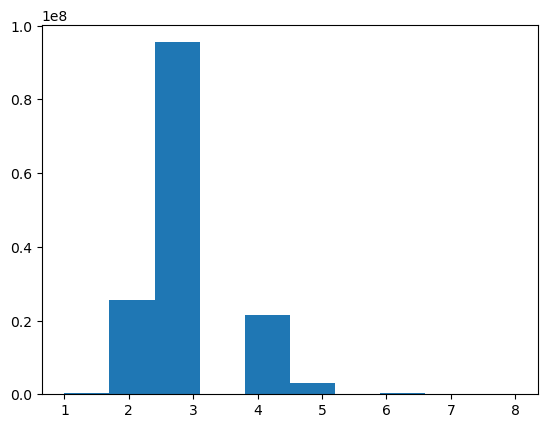

In [143]:
plt.hist(df_merged['shortest_path'])

In [144]:
import scipy.stats as stats
df_merged_dropna = df_merged.dropna(subset = ['shortest_path'])

user_cos_sim = df_merged_dropna['cos_sim'].to_list()
user_euc_dist = df_merged_dropna['euc_dist'].to_list()
user_jcd_sim = df_merged_dropna['jcd_sim'].to_list()

st_path = df_merged_dropna['shortest_path'].to_list()

rho_cos, p_val_cos = stats.pearsonr(user_cos_sim, st_path)
rho_euc, p_val_euc = stats.pearsonr(user_euc_dist, st_path)
rho_jcd, p_val_jcd = stats.pearsonr(user_jcd_sim, st_path)

print('코사인 유사도 기준 상관관계', rho_cos, p_val_cos)
print('유클리드 거리 기준 상관관계', rho_euc, p_val_euc)
print('자카드 유사도 기준 상관관계', rho_jcd, p_val_jcd)

코사인 유사도 기준 상관관계 -0.3258432657637904 0.0
유클리드 거리 기준 상관관계 -0.25364859507522264 0.0
자카드 유사도 기준 상관관계 -0.288112761854156 0.0


In [ ]:
# 리뷰 1000개 이상
# 그래프 노드 수: 32713
# 그래프 엣지 수: 40700
# 코사인 유사도 기준 상관관계 -0.29616445356106214 3.935688540695878e-09
# 유클리드 거리 기준 상관관계 -0.7212747434409958 2.936099988328002e-62
# 자카드 유사도 기준 상관관계 -0.7357369020410633 5.923527058758784e-66

# 리뷰 500개 이상
# 그래프 노드 수: 99876
# 그래프 엣지 수: 173639
# 코사인 유사도 기준 상관관계 -0.2945300199907544 0.0
# 유클리드 거리 기준 상관관계 -0.43897222229477695 0.0
# 자카드 유사도 기준 상관관계 -0.48233635591533475 0.0

# 리뷰 200개 이상
# 그래프 노드 수: 266686
# 그래프 엣지 수: 551655
# 코사인 유사도 기준 상관관계 -0.3707174924228415 0.0
# 유클리드 거리 기준 상관관계 -0.34767205330758366 0.0
# 자카드 유사도 기준 상관관계 -0.36265142909515463 0.0

# 리뷰 100개 이상
# 그래프 노드 수: 569492
# 그래프 엣지 수: 1142843
# 코사인 유사도 기준 상관관계 -0.4055230064992955 0.0
# 유클리드 거리 기준 상관관계 -0.3340778133633647 0.0
# 자카드 유사도 기준 상관관계 -0.3646228733838983 0.0

# 리뷰 50개 이상
# 그래프 노드 수: 1195631
# 그래프 엣지 수: 2408355
# 코사인 유사도 기준 상관관계 -0.3258432657637904 0.0
# 유클리드 거리 기준 상관관계 -0.25364859507522264 0.0
# 자카드 유사도 기준 상관관계 -0.288112761854156 0.0